# Japan Demographic Decline Analysis

Japan is generally considered the canary in the coal mine for demographic decline — populations are falling faster in Japan than just about any other industrialized nation, and they have been for some time.

This notebook analyzes population data for Japanese prefectures and cities from 1995 to 2020.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import openpyxl
import re
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

In [2]:
# Load japan-subdivisions.xlsx
subdivisions = pd.read_excel('japan-subdivisions.xlsx')
subdivisions.columns = ['Name', 'Status', 'Native', 'pop1995', 'pop2000', 'pop2005', 'pop2010', 'pop2015', 'pop2020', 'extra']
subdivisions = subdivisions.drop(columns=['extra'])

# Drop rows where pop1995 is missing
subdivisions = subdivisions.dropna(subset=['pop1995', 'pop2020'])

print(subdivisions['Status'].value_counts())
subdivisions.head()

Status
City (-shi)                           792
District (-gun)                       307
Prefecture                             46
Subprefecture (-sōgō-shinkō-kyoku)      9
Subprefecture (-shinkō-kyoku)           5
Subprefecture (-shichō)                 4
Metropolitan Prefecture                 1
Special Wards Area                      1
State                                   1
Name: count, dtype: int64


,Name,Status,Native,pop1995,pop2000,pop2005,pop2010,pop2015,pop2020
0,Aichi,Prefecture,愛知県,6868336,7043300,7254704,7410719,7483128,7542415
1,Aichi,District (-gun),愛知郡,32172,36878,39384,41851,42858,43903
2,Aisai,City (-shi),愛西市,64216,65597,65556,64978,63088,60829
3,Ama,City (-shi),あま市,78678,82321,85307,86714,86898,86126
4,Ama,District (-gun),海部郡,65822,67838,69620,71104,72472,74312


In [3]:
# Load japan-prefecture-areas.xlsx (Google Sheets export with IFERROR/DUMMYFUNCTION formulas)
def extract_cell_value(cell):
    """Extract embedded numeric/string value from IFERROR(DUMMYFUNCTION(...), VALUE) formula."""
    if cell.value is None:
        return None
    val = str(cell.value)
    m = re.search(r',([^)]+)\)\s*$', val)
    if m:
        v = m.group(1).strip().strip('"')
        try:
            return float(v)
        except ValueError:
            return v
    return cell.value

wb = openpyxl.load_workbook('japan-prefecture-areas.xlsx')
ws = wb.active

rows = []
for row in ws.iter_rows(min_row=3, max_row=50):
    vals = [extract_cell_value(c) for c in row]
    rows.append(vals)

areas_df = pd.DataFrame(rows, columns=['Rank', 'Prefecture', 'Japanese', 'Est_Area_km2',
                                        'Det_Area_km2', 'Undet_Area', 'Population',
                                        'Density_per_km2', 'Inhab_Area_km2',
                                        'Inhab_Density', 'Forest_pct', 'Capital'])
areas_df = areas_df.dropna(subset=['Prefecture', 'Density_per_km2'])
# Remove the aggregate Japan row
areas_df = areas_df[areas_df['Prefecture'] != 'Japan']
areas_df = areas_df.reset_index(drop=True)

print(f"Prefectures with density data: {len(areas_df)}")
areas_df[['Prefecture', 'Est_Area_km2', 'Density_per_km2']].head()

Prefectures with density data: 47


,Prefecture,Est_Area_km2,Density_per_km2
0,Hokkaido,83424.31,64.51
1,Iwate,15275.01,83.77
2,Fukushima,13783.74,138.86
3,Nagano,13561.56,154.76
4,Niigata,12584.10,183.11


## Part A: Percentage Change in Population by Prefecture (1995–2020)

In [4]:
prefectures = subdivisions[subdivisions['Status'] == 'Prefecture'].copy()
prefectures['pct_change_1995_2020'] = (prefectures['pop2020'] - prefectures['pop1995']) / prefectures['pop1995'] * 100
prefectures = prefectures.sort_values('pct_change_1995_2020')

print(f"Number of prefectures: {len(prefectures)}")
print(f"\nTop 5 growing prefectures:")
print(prefectures[['Name', 'pop1995', 'pop2020', 'pct_change_1995_2020']].tail(5).to_string(index=False))
print(f"\nTop 5 declining prefectures:")
print(prefectures[['Name', 'pop1995', 'pop2020', 'pct_change_1995_2020']].head(5).to_string(index=False))

Number of prefectures: 46

Top 5 growing prefectures:
    Name  pop1995  pop2020  pct_change_1995_2020
 Saitama  6759311  7344765              8.661445
   Aichi  6868336  7542415              9.814299
   Shiga  1287005  1413610              9.837180
Kanagawa  8245903  9237337             12.023353
 Okinawa  1273440  1467480             15.237467

Top 5 declining prefectures:
    Name  pop1995  pop2020  pct_change_1995_2020
   Akita  1213667   959502            -20.941906
  Aomori  1481663  1237984            -16.446317
   Kōchi   816704   691527            -15.327095
Nagasaki  1544934  1312317            -15.056760
Yamagata  1256958  1068027            -15.030812


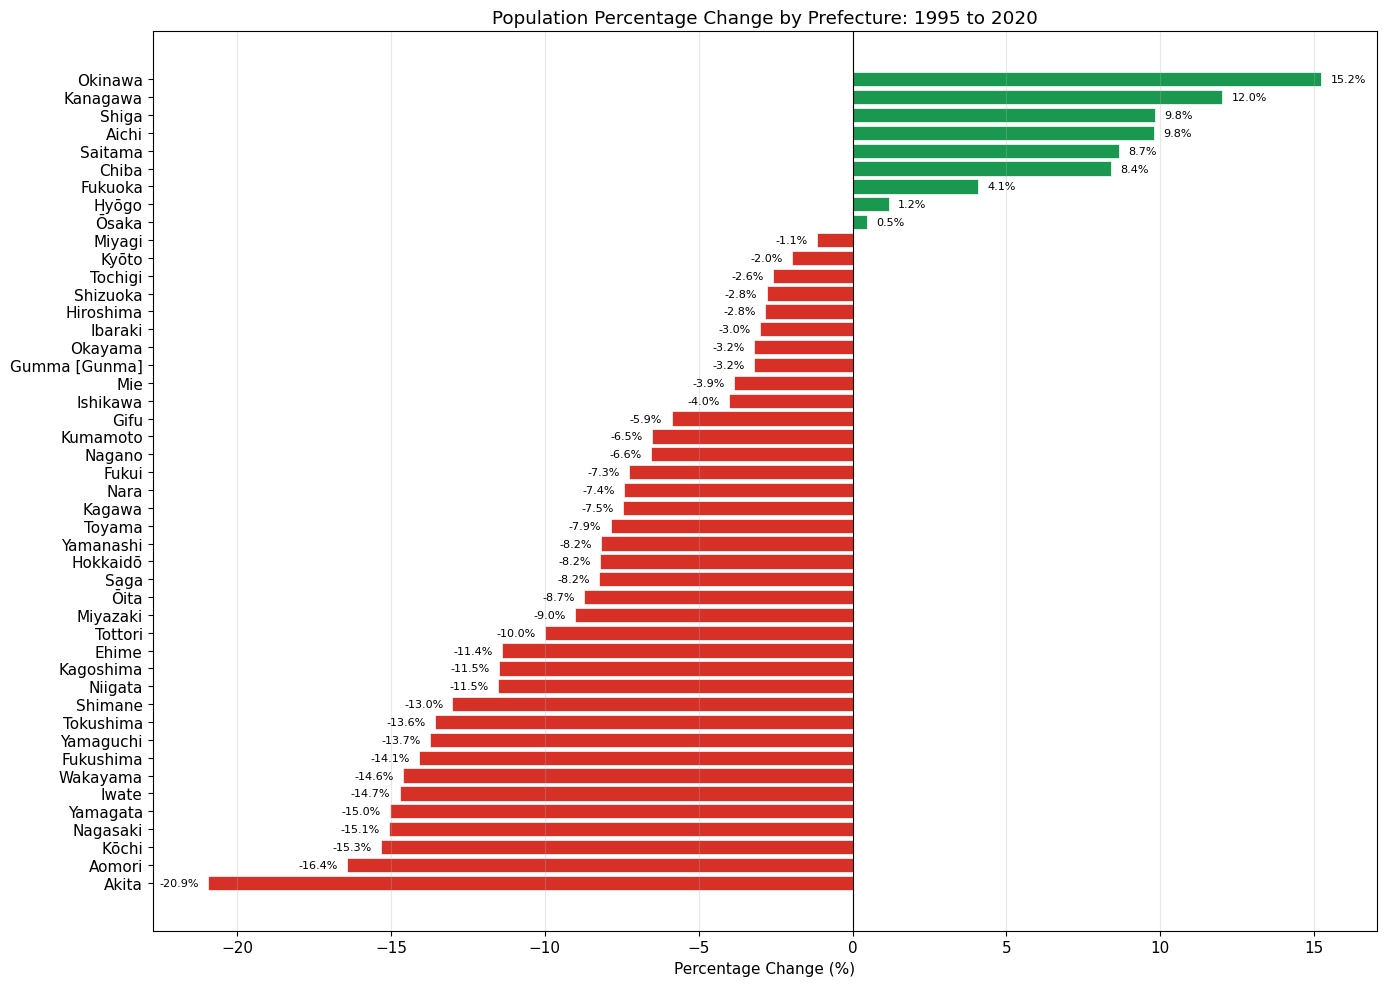

In [5]:
fig, ax = plt.subplots(figsize=(14, 10))

colors = ['#d73027' if x < 0 else '#1a9850' for x in prefectures['pct_change_1995_2020']]
bars = ax.barh(prefectures['Name'], prefectures['pct_change_1995_2020'], color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Percentage Change (%)')
ax.set_title('Population Percentage Change by Prefecture: 1995 to 2020')
ax.grid(axis='x', alpha=0.3)

# Annotate bars with values
for bar, val in zip(bars, prefectures['pct_change_1995_2020']):
    offset = 0.3 if val >= 0 else -0.3
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('q_a_prefecture_pct_changes.png', dpi=150, bbox_inches='tight')
plt.show()

## Part B: Time Series of Percentage Change Relative to 1995

/tmp/ipykernel_1182457/910474978.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', n)


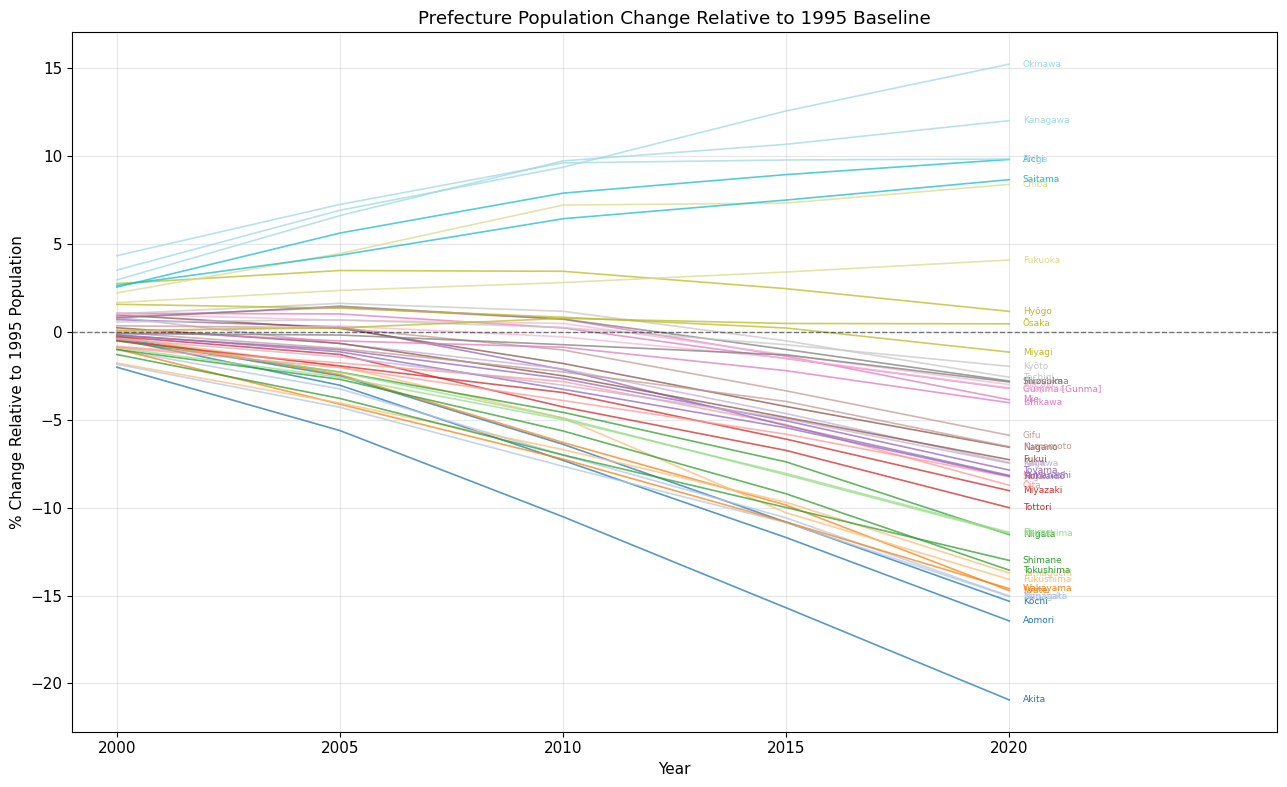

In [6]:
years = [2000, 2005, 2010, 2015, 2020]
year_cols = ['pop2000', 'pop2005', 'pop2010', 'pop2015', 'pop2020']

fig, ax = plt.subplots(figsize=(13, 8))

n = len(prefectures)
cmap = cm.get_cmap('tab20', n)

for i, (_, row) in enumerate(prefectures.iterrows()):
    pct_changes = [(row[col] - row['pop1995']) / row['pop1995'] * 100 for col in year_cols]
    ax.plot(years, pct_changes, color=cmap(i), linewidth=1.2, alpha=0.75, label=row['Name'])
    # Label at the end of each line
    ax.text(2020.3, pct_changes[-1], row['Name'], fontsize=6.5, va='center', color=cmap(i))

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('% Change Relative to 1995 Population')
ax.set_title('Prefecture Population Change Relative to 1995 Baseline')
ax.set_xticks(years)
ax.grid(alpha=0.3)
ax.set_xlim(1999, 2026)

plt.tight_layout()
plt.savefig('q_b_prefecture_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Part C: Does 1995 Population Predict Percentage Change 1995–2020?

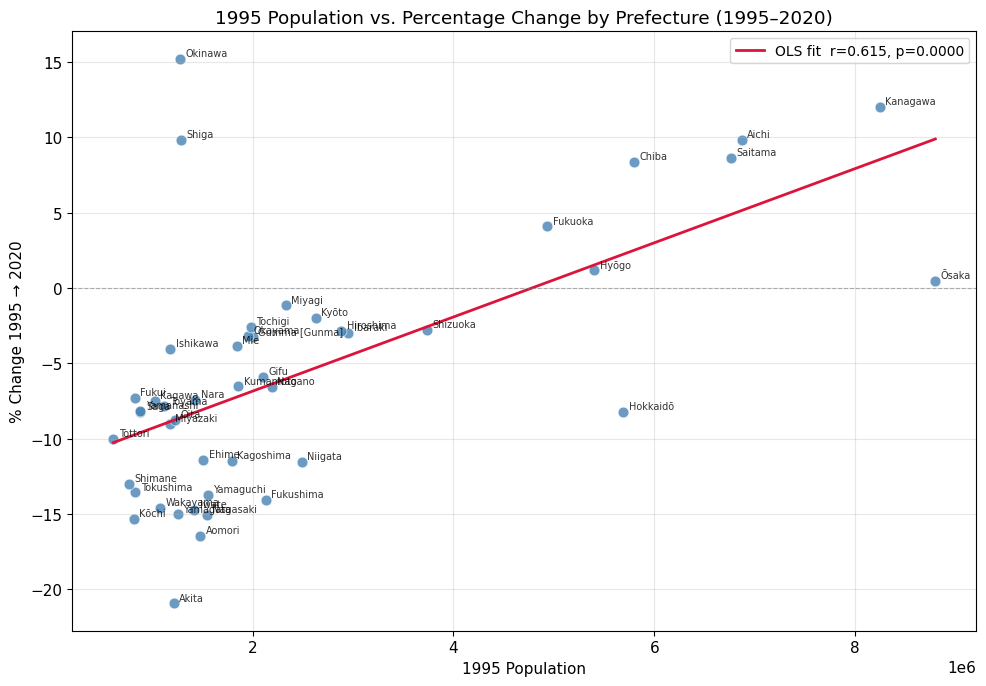

Pearson r = 0.6149,  p-value = 0.0000
Slope: 2.46e-06 (% change per additional person in 1995 population)


In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(prefectures['pop1995'], prefectures['pct_change_1995_2020'],
           s=60, alpha=0.8, color='steelblue', edgecolors='white', linewidth=0.5)

for _, row in prefectures.iterrows():
    ax.annotate(row['Name'], (row['pop1995'], row['pct_change_1995_2020']),
                fontsize=7, xytext=(4, 2), textcoords='offset points', alpha=0.8)

# Linear regression
slope, intercept, r, p, se = stats.linregress(prefectures['pop1995'], prefectures['pct_change_1995_2020'])
x_line = np.linspace(prefectures['pop1995'].min(), prefectures['pop1995'].max(), 200)
ax.plot(x_line, slope * x_line + intercept, color='crimson', linewidth=2,
        label=f'OLS fit  r={r:.3f}, p={p:.4f}')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('1995 Population')
ax.set_ylabel('% Change 1995 → 2020')
ax.set_title('1995 Population vs. Percentage Change by Prefecture (1995–2020)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q_c_scatter_pop1995_vs_pctchange.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r = {r:.4f},  p-value = {p:.4f}")
print(f"Slope: {slope:.2e} (% change per additional person in 1995 population)")

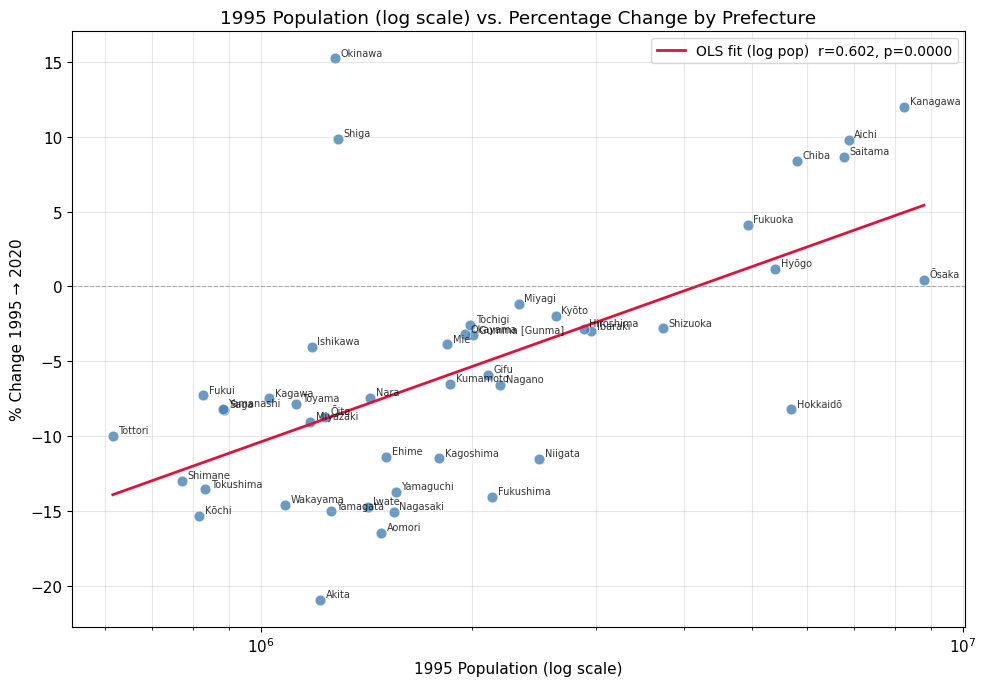

Pearson r (log population) = 0.6023,  p-value = 0.0000


In [8]:
# Also try log scale on x-axis since population spans orders of magnitude
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(prefectures['pop1995'], prefectures['pct_change_1995_2020'],
           s=60, alpha=0.8, color='steelblue', edgecolors='white', linewidth=0.5)

for _, row in prefectures.iterrows():
    ax.annotate(row['Name'], (row['pop1995'], row['pct_change_1995_2020']),
                fontsize=7, xytext=(4, 2), textcoords='offset points', alpha=0.8)

log_pop = np.log10(prefectures['pop1995'])
slope_log, intercept_log, r_log, p_log, _ = stats.linregress(log_pop, prefectures['pct_change_1995_2020'])
x_log = np.linspace(log_pop.min(), log_pop.max(), 200)
ax.plot(10**x_log, slope_log * x_log + intercept_log, color='crimson', linewidth=2,
        label=f'OLS fit (log pop)  r={r_log:.3f}, p={p_log:.4f}')

ax.set_xscale('log')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('1995 Population (log scale)')
ax.set_ylabel('% Change 1995 → 2020')
ax.set_title('1995 Population (log scale) vs. Percentage Change by Prefecture')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('q_c_scatter_logpop_vs_pctchange.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (log population) = {r_log:.4f},  p-value = {p_log:.4f}")

## Part D: Cities — Does City Size Relate to Percentage Change?

In [9]:
cities = subdivisions[subdivisions['Status'] == 'City (-shi)'].copy()
cities['pct_change_1995_2020'] = (cities['pop2020'] - cities['pop1995']) / cities['pop1995'] * 100
cities = cities.dropna(subset=['pop1995', 'pct_change_1995_2020'])

print(f"Number of cities: {len(cities)}")
print(f"Population range: {cities['pop1995'].min():,.0f} – {cities['pop1995'].max():,.0f}")
print(f"\nMean % change: {cities['pct_change_1995_2020'].mean():.2f}%")
print(f"Median % change: {cities['pct_change_1995_2020'].median():.2f}%")
print(f"Cities that grew: {(cities['pct_change_1995_2020'] > 0).sum()}")
print(f"Cities that shrank: {(cities['pct_change_1995_2020'] < 0).sum()}")

Number of cities: 792
Population range: 6,867 – 3,307,136

Mean % change: -6.44%
Median % change: -8.03%
Cities that grew: 275
Cities that shrank: 517


/tmp/ipykernel_1182457/3968528492.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(groups, labels=['Q1\n(Smallest)', 'Q2', 'Q3', 'Q4\n(Largest)'],


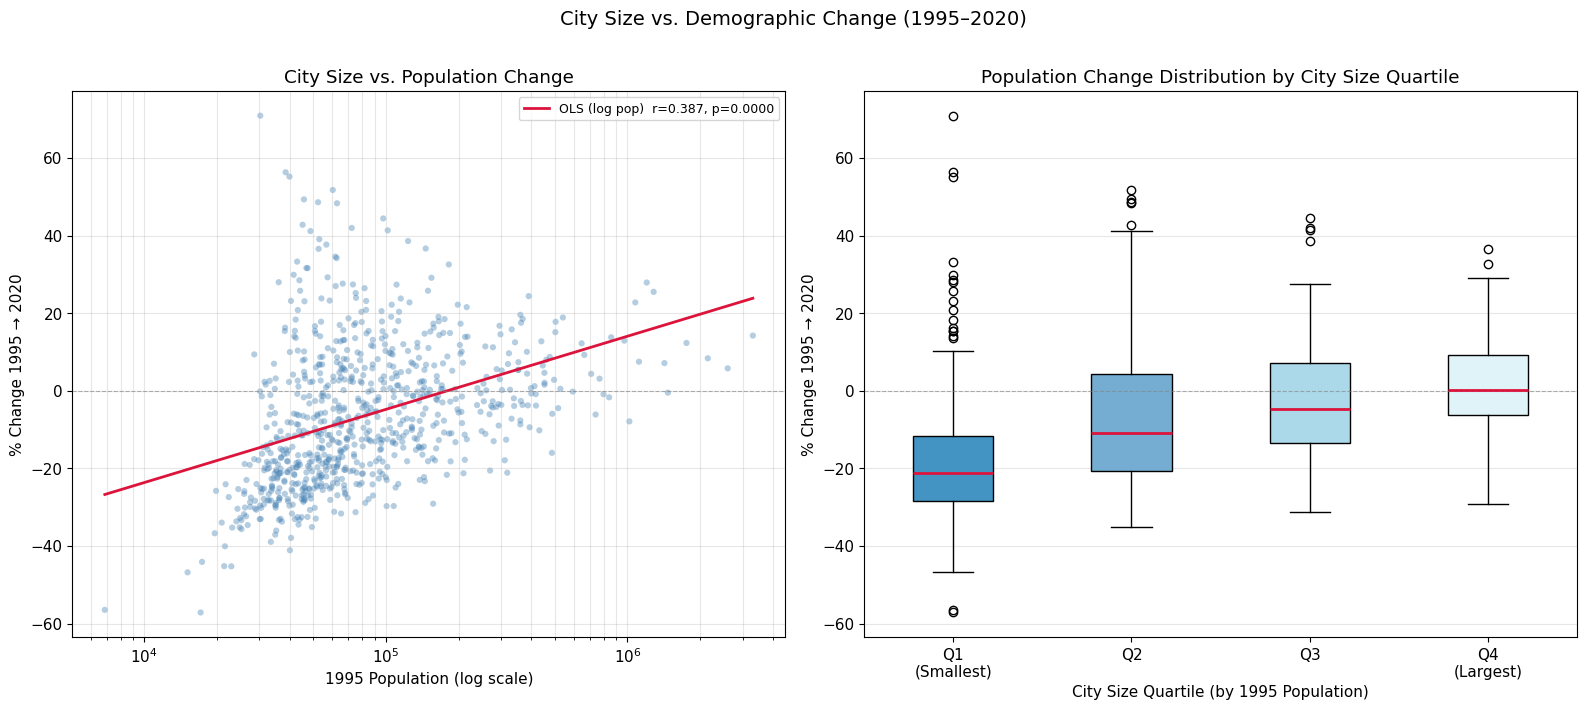

Pearson r (log city pop 1995 vs % change) = 0.3868,  p-value = 0.0000

Median % change by quartile:
size_quartile
Q1\n(Smallest)   -21.273846
Q2               -10.829866
Q3                -4.709434
Q4\n(Largest)      0.224034


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: scatter plot (log scale x)
ax = axes[0]
ax.scatter(cities['pop1995'], cities['pct_change_1995_2020'],
           s=20, alpha=0.4, color='steelblue', edgecolors='none')

log_pop_cities = np.log10(cities['pop1995'])
slope_c, intercept_c, r_c, p_c, _ = stats.linregress(log_pop_cities, cities['pct_change_1995_2020'])
x_log_c = np.linspace(log_pop_cities.min(), log_pop_cities.max(), 200)
ax.plot(10**x_log_c, slope_c * x_log_c + intercept_c, color='crimson', linewidth=2,
        label=f'OLS (log pop)  r={r_c:.3f}, p={p_c:.4f}')

ax.set_xscale('log')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('1995 Population (log scale)')
ax.set_ylabel('% Change 1995 → 2020')
ax.set_title('City Size vs. Population Change')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

# Right: box plot by city size quartile
ax2 = axes[1]
cities['size_quartile'] = pd.qcut(cities['pop1995'], q=4,
                                   labels=['Q1\n(Smallest)', 'Q2', 'Q3', 'Q4\n(Largest)'])
groups = [cities[cities['size_quartile'] == q]['pct_change_1995_2020']
          for q in ['Q1\n(Smallest)', 'Q2', 'Q3', 'Q4\n(Largest)']]
bp = ax2.boxplot(groups, labels=['Q1\n(Smallest)', 'Q2', 'Q3', 'Q4\n(Largest)'],
                 patch_artist=True, medianprops=dict(color='crimson', linewidth=2))
colors_box = ['#4393c3', '#74add1', '#abd9e9', '#e0f3f8']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.set_xlabel('City Size Quartile (by 1995 Population)')
ax2.set_ylabel('% Change 1995 → 2020')
ax2.set_title('Population Change Distribution by City Size Quartile')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('City Size vs. Demographic Change (1995–2020)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('q_d_cities_size_vs_change.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (log city pop 1995 vs % change) = {r_c:.4f},  p-value = {p_c:.4f}")
print("\nMedian % change by quartile:")
print(cities.groupby('size_quartile', observed=True)['pct_change_1995_2020'].median().to_string())

## Part E: Population Density vs. Percentage Change (Prefectures)

In [11]:
# Merge prefecture population change with density data
# Standardize names for matching
prefectures_merge = prefectures[['Name', 'pop1995', 'pct_change_1995_2020']].copy()
areas_merge = areas_df[['Prefecture', 'Density_per_km2']].copy()

merged = pd.merge(prefectures_merge, areas_merge,
                  left_on='Name', right_on='Prefecture', how='inner')
print(f"Matched prefectures: {len(merged)}")

# Check which didn't match
unmatched_pref = set(prefectures_merge['Name']) - set(merged['Name'])
unmatched_area = set(areas_merge['Prefecture']) - set(merged['Prefecture'])
if unmatched_pref:
    print(f"Unmatched from subdivisions: {sorted(unmatched_pref)}")
if unmatched_area:
    print(f"Unmatched from areas: {sorted(unmatched_area)}")

Matched prefectures: 39
Unmatched from subdivisions: ['Gumma [Gunma]', 'Hokkaidō', 'Hyōgo', 'Kyōto', 'Kōchi', 'Ōita', 'Ōsaka']
Unmatched from areas: ['Gunma', 'Hokkaido', 'Hyogo', 'Kochi', 'Kyoto', 'Oita', 'Osaka', 'Tokyo']


In [12]:
# Manual name corrections for the few that don't auto-match
name_map = {
    'Kanagawa': 'Kanagawa',  # check spelling
}
# Apply any needed fixes
areas_merge_fixed = areas_merge.copy()
# From the unmatched output above, patch manually if needed
fix_map = {}  # will fill in if unmatched shows anything

merged_full = pd.merge(prefectures_merge, areas_merge_fixed,
                       left_on='Name', right_on='Prefecture', how='inner')
print(f"Final matched prefectures: {len(merged_full)}")

Final matched prefectures: 39


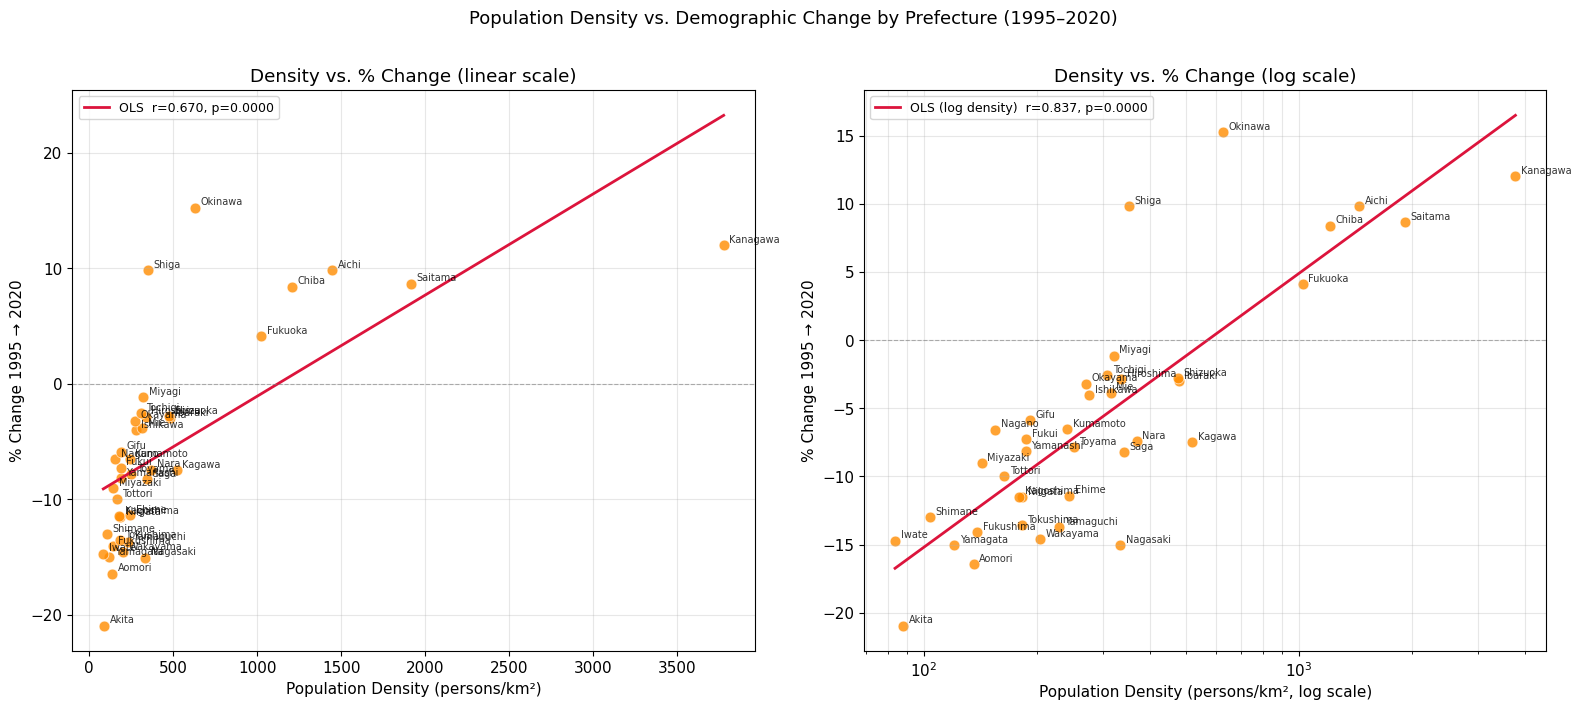

Linear density:  r = 0.6698,  p = 0.0000
Log density:     r = 0.8366,  p = 0.0000


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: density vs % change (linear scale)
ax = axes[0]
ax.scatter(merged_full['Density_per_km2'], merged_full['pct_change_1995_2020'],
           s=60, alpha=0.8, color='darkorange', edgecolors='white', linewidth=0.5)
for _, row in merged_full.iterrows():
    ax.annotate(row['Name'], (row['Density_per_km2'], row['pct_change_1995_2020']),
                fontsize=7, xytext=(4, 2), textcoords='offset points', alpha=0.8)

slope_d, intercept_d, r_d, p_d, _ = stats.linregress(
    merged_full['Density_per_km2'], merged_full['pct_change_1995_2020'])
x_d = np.linspace(merged_full['Density_per_km2'].min(), merged_full['Density_per_km2'].max(), 200)
ax.plot(x_d, slope_d * x_d + intercept_d, color='crimson', linewidth=2,
        label=f'OLS  r={r_d:.3f}, p={p_d:.4f}')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Population Density (persons/km²)')
ax.set_ylabel('% Change 1995 → 2020')
ax.set_title('Density vs. % Change (linear scale)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: log density vs % change
ax2 = axes[1]
ax2.scatter(merged_full['Density_per_km2'], merged_full['pct_change_1995_2020'],
            s=60, alpha=0.8, color='darkorange', edgecolors='white', linewidth=0.5)
for _, row in merged_full.iterrows():
    ax2.annotate(row['Name'], (row['Density_per_km2'], row['pct_change_1995_2020']),
                 fontsize=7, xytext=(4, 2), textcoords='offset points', alpha=0.8)

log_density = np.log10(merged_full['Density_per_km2'])
slope_dl, intercept_dl, r_dl, p_dl, _ = stats.linregress(log_density, merged_full['pct_change_1995_2020'])
x_dl = np.linspace(log_density.min(), log_density.max(), 200)
ax2.plot(10**x_dl, slope_dl * x_dl + intercept_dl, color='crimson', linewidth=2,
         label=f'OLS (log density)  r={r_dl:.3f}, p={p_dl:.4f}')
ax2.set_xscale('log')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.set_xlabel('Population Density (persons/km², log scale)')
ax2.set_ylabel('% Change 1995 → 2020')
ax2.set_title('Density vs. % Change (log scale)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, which='both')

plt.suptitle('Population Density vs. Demographic Change by Prefecture (1995–2020)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('q_e_density_vs_pctchange.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Linear density:  r = {r_d:.4f},  p = {p_d:.4f}")
print(f"Log density:     r = {r_dl:.4f},  p = {p_dl:.4f}")